In [1]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
name = "studentportuguese"
namex = "Portuguese"

d = 30

###threshold
graphsx = np.load("../graphs/"+name+"_thresh_random.npy", allow_pickle=True)


## Info on the graphs

In [3]:
######
randomgraphsinfo = pd.read_csv("../graphs/studentportuguese_thresh_graphsummary.npy")
randomgraphsinfo


,Dataset (d),r,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Student-portguese (30),4.0,224,6,5,1,0.035714,0.031250,0.004464,1.333333,0.001810,0.001810,0.000000,4,0,219,2,0
1,Student-portguese (30),4.5,224,22,13,9,0.214286,0.165179,0.049107,2.181818,0.011933,0.011592,0.000341,18,6,196,0,1
2,Student-portguese (30),5.0,224,32,18,14,0.665179,0.540179,0.125000,4.656250,0.059369,0.057328,0.002041,32,8,169,0,2
3,Student-portguese (30),5.5,224,39,20,19,1.500000,1.044643,0.455357,8.615385,0.146890,0.122548,0.024342,30,28,129,0,3
4,Student-portguese (30),6.0,224,44,20,24,3.433036,2.129464,1.303571,17.477273,0.470476,0.328889,0.141587,26,40,77,0,4
5,Student-portguese (30),6.5,224,48,21,27,7.116071,4.312500,2.803571,33.208333,1.655986,1.134377,0.521610,15,29,41,0,5
6,Student-portguese (30),7.0,224,49,21,28,12.691964,7.169643,5.522321,58.020408,4.525781,2.862906,1.662874,6,22,20,0,6
7,Student-portguese (30),7.5,224,50,22,28,19.758929,10.526786,9.232143,88.520000,9.798838,5.790984,4.007854,4,16,7,0,7
8,Student-portguese (30),8.0,224,50,22,28,27.272321,13.718750,13.553571,122.180000,17.218596,9.356865,7.861731,1,7,3,0,8
9,Student-portguese (30),8.5,224,50,22,28,34.062500,16.522321,17.540179,152.600000,25.435338,13.162676,12.272662,0,3,1,0,9


## Compute and evaluate results for the targeted intervention model

In [4]:
summary_dfx = scripts.analytics.compute_itm_results(datasgraphs = graphsx,
                                                      thresh=True,
                                                      dsetname = name,
                                                      dsetdim = d)

summary_dfx.to_csv("./im_results/"+name+"_boost_results_thresh.csv", index=False)
summary_dfx.head(10)

,K,B,Sg,Sg_lbls,F(Sg),Sgb,Sgb_lbls,F(Sgb)b4B,F(Sgb),Boostedgb,...,Boostedbg,usedBbudgetbg,r,n,m,greedyTime,greedyBoostTime,boostGreedyTime,dataset,graphid
0,1,4,{32},{32: -1},5.0,{32},{32: -1},5.0,9.0,"[0, 1, 2, 3]",...,"[0, 1, 2, 3]",4,4.0,224,6,0.004555,0.004888,0.004908,studentportuguese (30),0
1,1,3,{32},{32: -1},5.0,{32},{32: -1},5.0,8.0,"[0, 1, 2]",...,"[0, 1, 2]",3,4.0,224,6,0.004400,0.009836,0.005140,studentportuguese (30),0
2,1,2,{32},{32: -1},5.0,{32},{32: -1},5.0,7.0,"[0, 1]",...,"[0, 1]",2,4.0,224,6,0.005468,0.006391,0.006947,studentportuguese (30),0
3,1,1,{32},{32: -1},5.0,{32},{32: -1},5.0,6.0,[0],...,[0],1,4.0,224,6,0.007359,0.006741,0.005264,studentportuguese (30),0
4,1,0,{32},{32: -1},5.0,{32},{32: -1},5.0,5.0,[],...,[],0,4.0,224,6,0.003980,0.004952,0.007681,studentportuguese (30),0
5,2,4,{32},{32: -1},5.0,{32},{32: -1},5.0,9.0,"[0, 1, 2, 3]",...,"[0, 1, 2, 3]",4,4.0,224,6,0.009283,0.008496,0.007690,studentportuguese (30),0
6,2,3,{32},{32: -1},5.0,{32},{32: -1},5.0,8.0,"[0, 1, 2]",...,"[0, 1, 2]",3,4.0,224,6,0.024081,0.008067,0.023220,studentportuguese (30),0
7,2,2,{32},{32: -1},5.0,{32},{32: -1},5.0,7.0,"[0, 1]",...,"[0, 1]",2,4.0,224,6,0.009862,0.007976,0.011873,studentportuguese (30),0
8,2,1,{32},{32: -1},5.0,{32},{32: -1},5.0,6.0,[0],...,[0],1,4.0,224,6,0.007276,0.008725,0.008848,studentportuguese (30),0
9,2,0,{32},{32: -1},5.0,{32},{32: -1},5.0,5.0,[],...,[],0,4.0,224,6,0.008778,0.010232,0.007997,studentportuguese (30),0


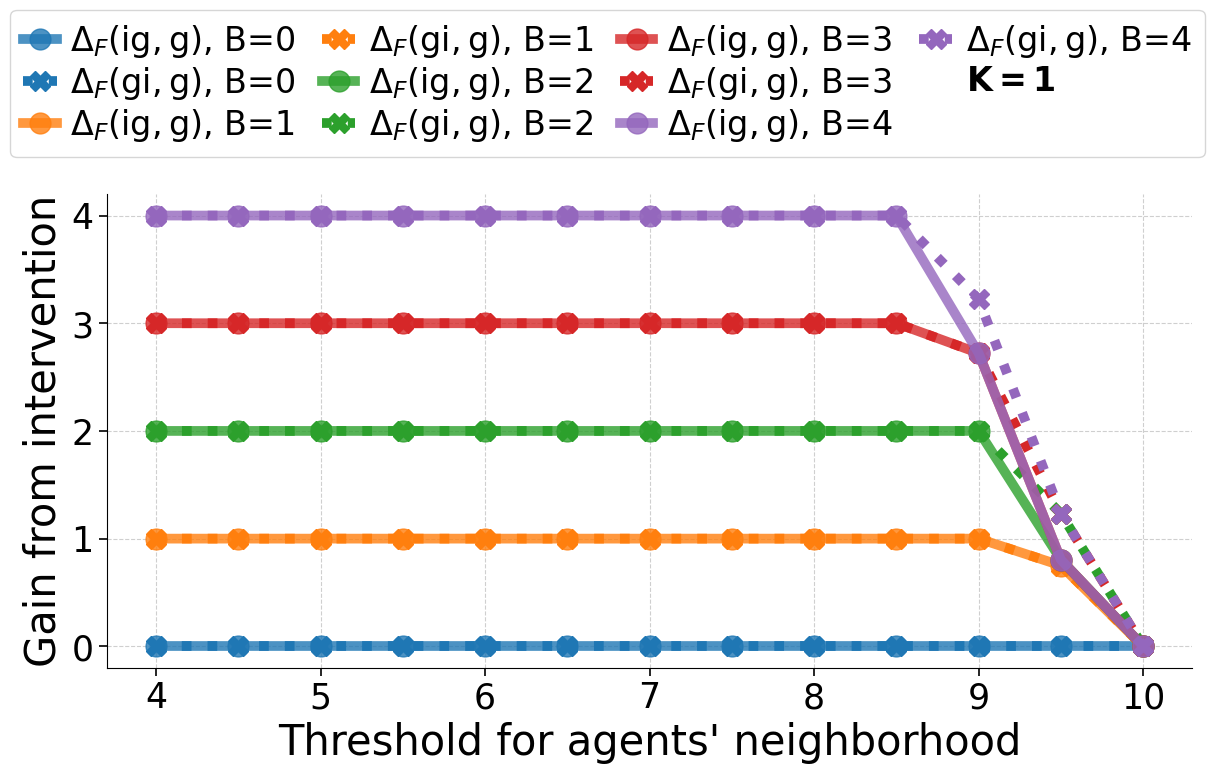

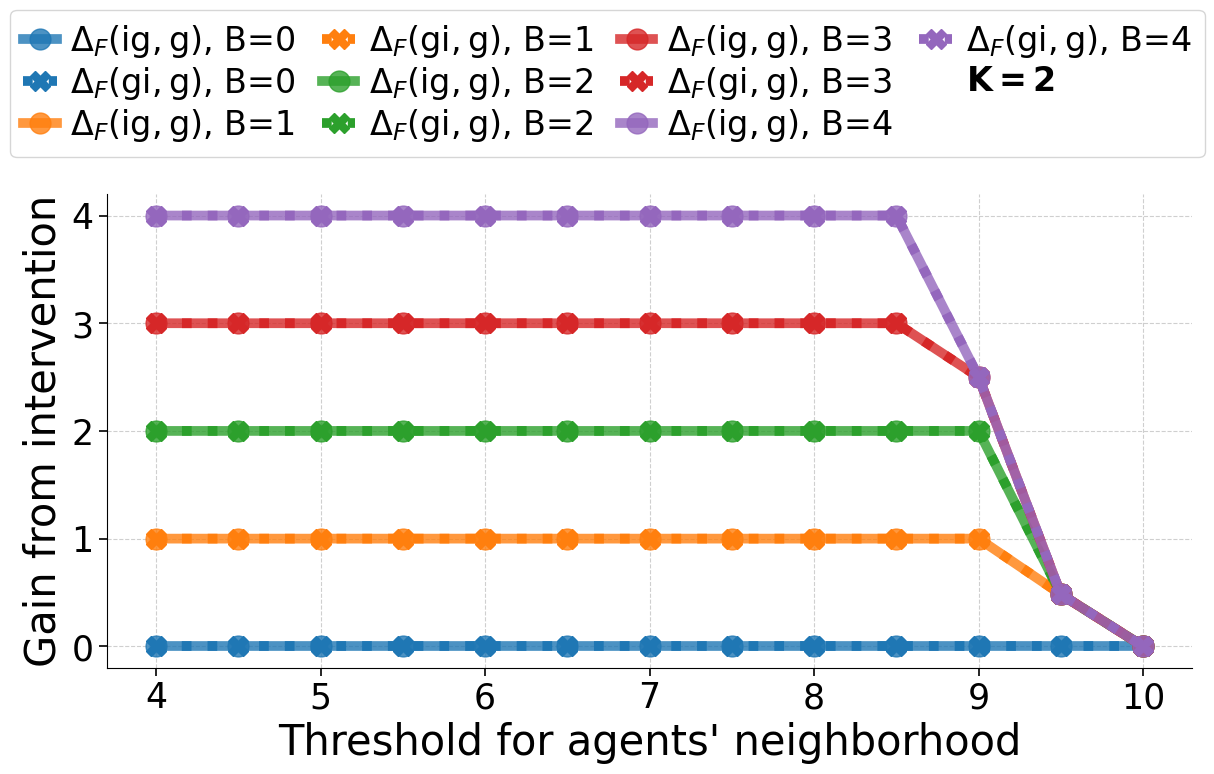

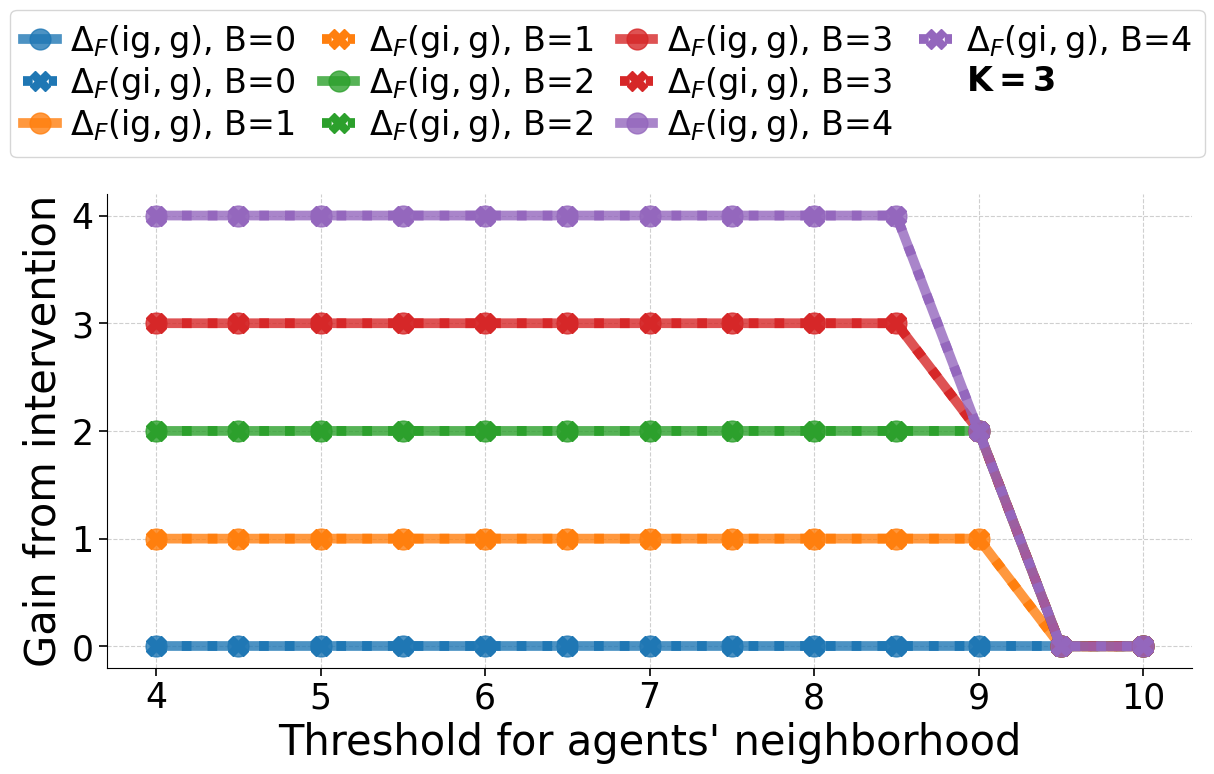

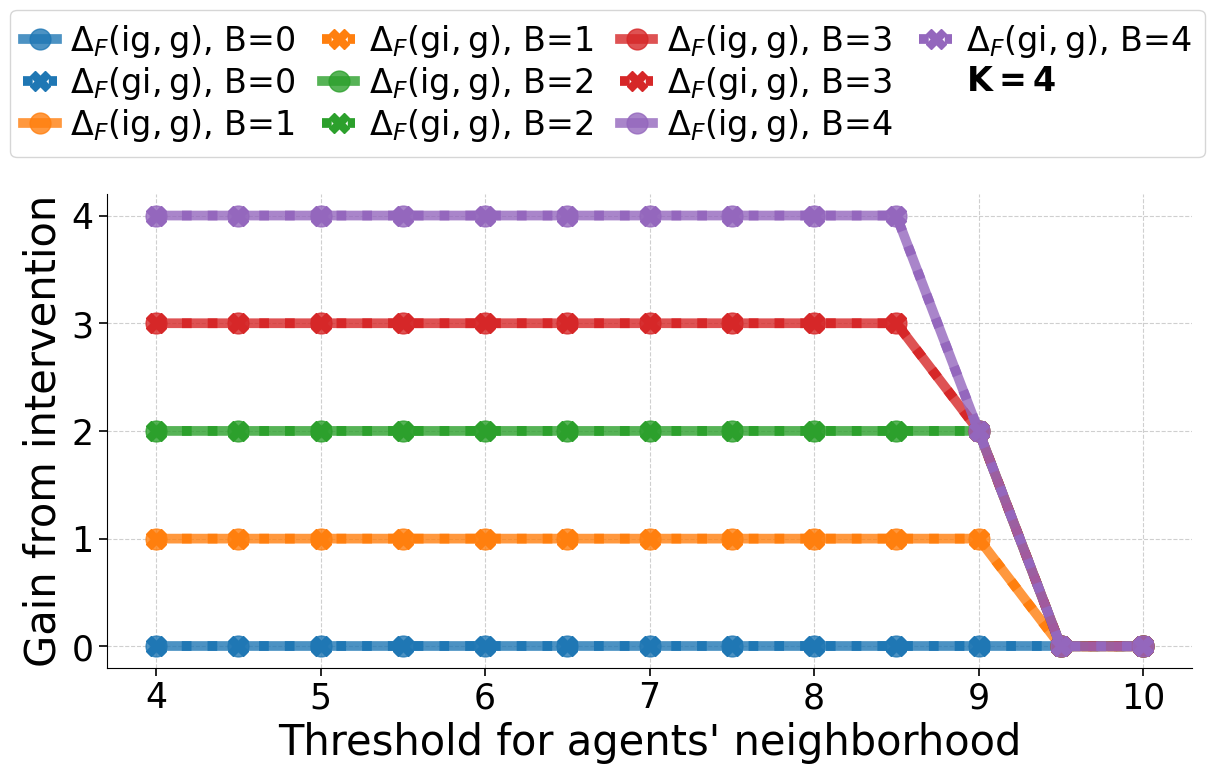

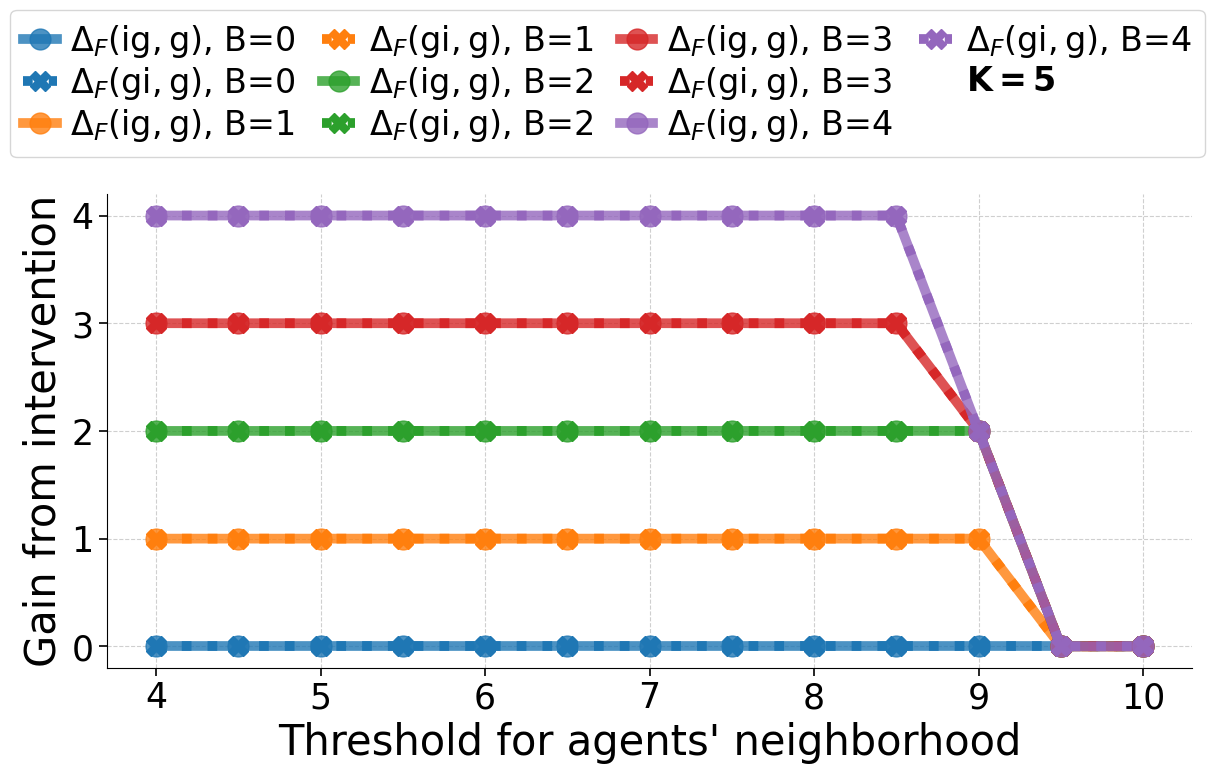

In [5]:
scripts.analytics.plot_intm_results(resdf = summary_dfx,
                          thresh = True, 
                          save_as = "./im_results/figures/"+name+"_imb4aftersm_results_thresh")